# F16 GCAS — CBF / R-CBF-QP / Duality CBF / Dual-Phi CBF

Loads a pre-trained PNCBF checkpoint for `F16GCAS` and compares four
measurement-robust CBF policies under additive state-space noise.

**Uncertainty model:** at each step the true state `x` is observed as
`xhat = x + δ` where `δ ∈ [−STATE_EPS, STATE_EPS]` (per-component).
The uncertainty set is the box `[xhat − STATE_EPS, xhat + STATE_EPS]`;
no NNV propagation is needed (unlike the double-integrator notebook).

**Policies:**
- **CBF** — min-norm QP at the nominal `xhat`
- **R-CBF-QP** — sampling-based robustification with linear correction
- **Duality CBF** — supporting-hyperplane approach over the uncertainty image set (nu=3 → 4D directions on S³)
- **Dual-Phi CBF** — learned scalar correction trained with dual-direction labels

In [23]:
import functools as ft
import pathlib
import sys
sys.path.insert(0, '../../src')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import flax.linen as nn
import optax
import time

from mrncbf.utils.jax_utils import jax_default_x32
from mrncbf.qp.min_norm_cbf import min_norm_cbf, gcbf_qp, rcbf_qp_linear, compute_rcbf_gammas
from mrncbf.dyn.f16_gcas import F16GCAS
from mrncbf.pncbf.pncbf import PNCBF
from mrncbf.utils.ckpt_utils import load_ckpt
import run_config.int_avoid.f16gcas_cfg

jax_default_x32()

# ── Checkpoint path — set this to your trained F16 run ───────────────────────
CKPT_PATH = pathlib.Path(
    "../../runs/pncbf_f16gcas/2026-04-19_14-20_HWIB_acl-lambda-01_f16/ckpts/100000"
)

# ── QP / filter parameters ───────────────────────────────────────────────────
ALPHA_QP  = 0.01    # small: neural V is not Lipschitz-normalised
V_SHIFT   = 1e-2    # widen the safe set slightly

# ── State-space noise bounds (per-component) ─────────────────────────────────
# Physically motivated sensor noise for F16.
# Order: VT ALPHA BETA PHI THETA PSI P Q R PN PE H POW NZINT PSINT NYRINT
STATE_EPS = jnp.array([
     5.0,   # VT     (ft/s)
     0.005, # ALPHA  (rad)
     0.005, # BETA   (rad)
     0.005, # PHI    (rad)
     0.005, # THETA  (rad)
     0.005, # PSI    (rad)
     0.01,  # P      (rad/s)
     0.01,  # Q      (rad/s)
     0.01,  # R      (rad/s)
     5.0,   # PN     (ft)
     5.0,   # PE     (ft)
    20.0,   # H      (ft)  — altitude, most safety-critical
     0.5,   # POW
     0.1,   # NZINT
     0.1,   # PSINT
     0.1,   # NYRINT
])

# ── Robust-policy parameters ─────────────────────────────────────────────────
N_RCBF_SAMPLES = 32
N_PLANES_DUAL  = 16   # directions on S³ (nu+1=4 dimensional)
N_LABEL_SAMPLES = 64  # samples for dual-phi label generation

# ── Dual directions on S³ (unit vectors in R^{nu+1} = R^4) ───────────────────
_rng_dirs = np.random.default_rng(0)
_raw = _rng_dirs.standard_normal((N_PLANES_DUAL, 4))
_DUAL_DIRS = (_raw / np.linalg.norm(_raw, axis=1, keepdims=True)).astype(np.float32)
# Convert to Python float tuples so they stay concrete inside JIT
_DUAL_DIRS_PY = [tuple(float(v) for v in _DUAL_DIRS[j]) for j in range(N_PLANES_DUAL)]


2026-04-20 14:58:30.318 | INFO     | mrncbf.pncbf.pncbf:create:175 - Discount lam: SchedCts(Lin(80 -> 500, s500000, w100000), dt=0.04)


Loaded checkpoint from ../../runs/pncbf_f16gcas/2026-04-19_14-20_HWIB_acl-lambda-01_f16/ckpts/100000
Task: nh=10  nx=16  nu=3  dt=0.04


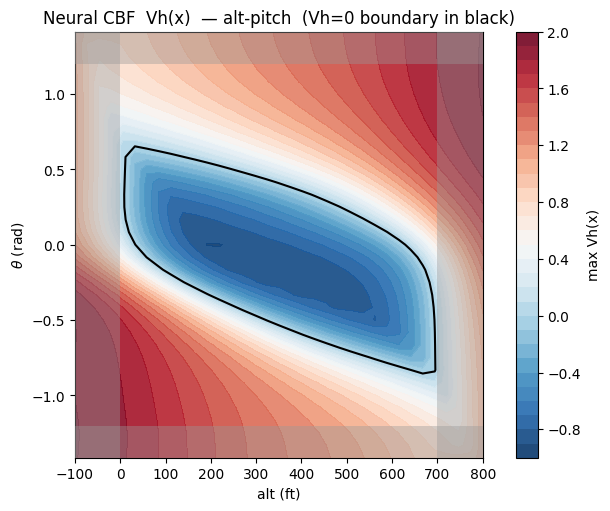

In [24]:
seed = 7957821
task = F16GCAS()
CFG  = run_config.int_avoid.f16gcas_cfg.get(seed)
alg  = PNCBF.create(seed, task, CFG.alg_cfg, task.nom_pol_pid)
with jax.default_device(jax.devices()[0]):
    alg = load_ckpt(alg, CKPT_PATH.absolute())
print(f"Loaded checkpoint from {CKPT_PATH}")
print(f"Task: nh={task.nh}  nx={task.nx}  nu={task.nu}  dt={task.dt}")

DT = task.dt    # 0.04 s
T  = 300        # 12 s rollout
ts = np.arange(T + 1) * DT

_NH = task.nh       # 10
_nu = task.nu       # 3

# Pre-built index arrays for vmap over all (_NH × N_PLANES_DUAL) pairs in duality step
_IJ_CONSTRAINTS = jnp.repeat(jnp.arange(_NH), N_PLANES_DUAL)           # (_NH*N_PLANES_DUAL,)
_IJ_DIRS_JAX    = jnp.tile(jnp.array(_DUAL_DIRS, dtype=jnp.float32), (_NH, 1))  # (_NH*N_PLANES_DUAL, 4)

u_lb = jnp.array(task.u_min)   # [-1, -5, -5]
u_ub = jnp.array(task.u_max)   # [ 6,  5,  5]

# ── Neural CBF ────────────────────────────────────────────────────────────────
def B_nn(x):
    return alg.get_Vh(x) + V_SHIFT

def _gcbf_ingredients(x):
    h_V   = B_nn(x)
    hx_Vx = jax.jacobian(B_nn)(x)   # (nh, nx)
    return h_V, hx_Vx @ task.f(x), hx_Vx @ task.G(x)

# ── Visualise Vh on the alt-pitch grid ───────────────────────────────────────
n_grid = 35
bb_x0, bb_Xs, bb_Ys = task.get_contour_x0(0, n_pts=n_grid)   # setup 0 = altpitch
bb_Vh = jax.vmap(jax.vmap(alg.get_Vh))(bb_x0)                # (n, n, nh)
bb_Vh_max = np.array(bb_Vh.max(-1))                           # (n, n)

fig, ax = plt.subplots(figsize=(6, 5), layout='constrained')
cs = ax.contourf(bb_Xs, bb_Ys, bb_Vh_max, levels=31, cmap='RdBu_r', alpha=0.9)
ax.contour(bb_Xs, bb_Ys, bb_Vh_max, levels=[0.0], colors=['k'], linewidths=1.5)
fig.colorbar(cs, ax=ax, label='max Vh(x)')
task.plot_altpitch(ax)
ax.set_title('Neural CBF  Vh(x)  — alt-pitch  (Vh=0 boundary in black)')
plt.show()

In [25]:
## Rollout infrastructure

BASE_KEY = jax.random.PRNGKey(0)

# Dangerous initial conditions: low altitude, nose-down
x_trim = jnp.array(task.eq_state())
x0_demo = x_trim.at[task.H].set(200.0).at[task.THETA].set(-0.4)
print(f"Trim state  H={float(x_trim[task.H]):.1f} ft  theta={float(x_trim[task.THETA]):.4f} rad")
print(f"Demo  x0    H={float(x0_demo[task.H]):.1f} ft  theta={float(x0_demo[task.THETA]):.4f} rad")
print(f"Vh(x0)={np.array(alg.get_Vh(x0_demo)).round(4)}  max={float(alg.get_Vh(x0_demo).max()):.4f}")

def _make_rollout(step_fn):
    @jax.jit
    def rollout(x0):
        _, (xs, xhats, los, his) = jax.lax.scan(step_fn, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0), xhats, los, his
    return rollout

def _perturb_state(x, key):
    """Add bounded uniform noise in state space."""
    delta = jax.random.uniform(key, x.shape, minval=STATE_EPS-0.00001, maxval=STATE_EPS)
    return x + delta

def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    x0s = lo[None] + jax.random.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]

x_dummy = x0_demo
print("Rollout infrastructure ready.")

Trim state  H=3600.0 ft  theta=0.0317 rad
Demo  x0    H=200.0 ft  theta=-0.4000 rad
Vh(x0)=[ 0.3143 -0.9586 -0.9669 -0.8511 -0.9359 -0.9882 -0.9807 -0.9617 -0.9642
 -0.9579]  max=0.3143
Rollout infrastructure ready.


In [26]:
## Policy step functions: CBF, R-CBF-QP, Duality CBF

# ── CBF ───────────────────────────────────────────────────────────────────────
def _cbf_step(x, step_idx):
    key  = jax.random.fold_in(BASE_KEY, step_idx)
    xhat = _perturb_state(x, key)
    h_V   = B_nn(xhat)
    hx_Vx = jax.jacobian(B_nn)(xhat)
    u_nom = task.nom_pol_pid(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_V, hx_Vx,
                            task.f(xhat), task.G(xhat), u_nom, relax_eps2=0.1)
    return x + DT * task.xdot(x, u), (x, xhat, xhat, xhat)

rollout_cbf = _make_rollout(_cbf_step)

# ── R-CBF-QP ──────────────────────────────────────────────────────────────────
def _rcbf_step(x, step_idx):
    key  = jax.random.fold_in(BASE_KEY, step_idx)
    noise_key, samp_key = jax.random.split(key)
    xhat = _perturb_state(x, noise_key)
    lo = jnp.clip(xhat - STATE_EPS, task.train_bounds()[0], task.train_bounds()[1])
    hi = jnp.clip(xhat + STATE_EPS, task.train_bounds()[0], task.train_bounds()[1])
    x_pert = lo[None] + jax.random.uniform(samp_key, (N_RCBF_SAMPLES, task.nx)) * (hi - lo)
    h_V_nom   = B_nn(xhat)
    hx_Vx_nom = jax.jacobian(B_nn)(xhat)
    u_nom     = task.nom_pol_pid(xhat)
    h_V_pert   = jax.vmap(B_nn)(x_pert)
    hx_Vx_pert = jax.vmap(jax.jacobian(B_nn))(x_pert)
    f_pert     = jax.vmap(task.f)(x_pert)
    G_pert     = jax.vmap(task.G)(x_pert)
    u_nom_pert = jax.vmap(task.nom_pol_pid)(x_pert)
    gamma1, gamma2 = compute_rcbf_gammas(
        alpha=ALPHA_QP, u_lb=u_lb, u_ub=u_ub,
        h_V_nom=h_V_nom, hx_Vx_nom=hx_Vx_nom,
        f_nom=task.f(xhat), G_nom=task.G(xhat), u_nom_base=u_nom,
        h_V_pert=h_V_pert, hx_Vx_pert=hx_Vx_pert,
        f_pert=f_pert, G_pert=G_pert, u_nom_pert=u_nom_pert, n_grid=20)
    u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub,
                              h_V_nom, hx_Vx_nom, task.f(xhat), task.G(xhat), u_nom,
                              gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
    return x + DT * task.xdot(x, u), (x, xhat, lo, hi)

rollout_rcbf = _make_rollout(_rcbf_step)

# ── Duality CBF ───────────────────────────────────────────────────────────────
# nu=3 → image set in R^4; _DUAL_DIRS are unit vectors on S³.
# Uses jax.vmap over all (_NH × N_PLANES_DUAL) (constraint, direction) pairs so
# JAX compiles the body *once* instead of tracing 160 separate graph nodes.
def _duality_step(x, step_idx):
    key  = jax.random.fold_in(BASE_KEY, step_idx)
    noise_key, opt_key = jax.random.split(key)
    xhat = _perturb_state(x, noise_key)
    lo = jnp.clip(xhat - STATE_EPS, task.train_bounds()[0], task.train_bounds()[1])
    hi = jnp.clip(xhat + STATE_EPS, task.train_bounds()[0], task.train_bounds()[1])
    u_nom = task.nom_pol_pid(xhat)

    n_pairs = _NH * N_PLANES_DUAL
    all_keys = jax.random.split(opt_key, n_pairs)

    def _worst_one(ci, d_vec, k_j):
        """Find ξ* that maximises the dual objective for constraint ci, direction d_vec."""
        def _obj(xi):
            h, Lf_h, LG_h = _gcbf_ingredients(xi)
            return jnp.dot(d_vec[:_nu], LG_h[ci]) + d_vec[_nu] * (Lf_h[ci] + ALPHA_QP * h[ci])
        _, x_star = proj_grad_max_box(_obj, lo, hi, n_restarts=4, n_steps=30, lr=0.02, key=k_j)
        h_s, Lf_s, LG_s = _gcbf_ingredients(x_star)
        return h_s[ci], Lf_s[ci], LG_s[ci]

    h_all, Lf_all, LG_all = jax.vmap(_worst_one)(_IJ_CONSTRAINTS, _IJ_DIRS_JAX, all_keys)
    # h_all / Lf_all: (n_pairs,)   LG_all: (n_pairs, nu)

    u, _, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub,
                       h_all, Lf_all, LG_all,
                       u_nom, relax_eps2=0.1)
    return x + DT * task.xdot(x, u), (x, xhat, lo, hi)

rollout_duality = _make_rollout(_duality_step)

print("Compiling CBF, R-CBF-QP, Duality CBF rollouts (first run takes a minute)...")
rollout_cbf(x_dummy)
print("  CBF done")
rollout_rcbf(x_dummy)
print("  R-CBF-QP done")
rollout_duality(x_dummy)
print("  Duality CBF done")

Compiling CBF, R-CBF-QP, Duality CBF rollouts (first run takes a minute)...
  CBF done
  R-CBF-QP done
  Duality CBF done


  CBF               alt_min=1.8 ft  violated: False
  R-CBF-QP          alt_min=2.2 ft  violated: False
  Duality CBF       alt_min=2.9 ft  violated: False


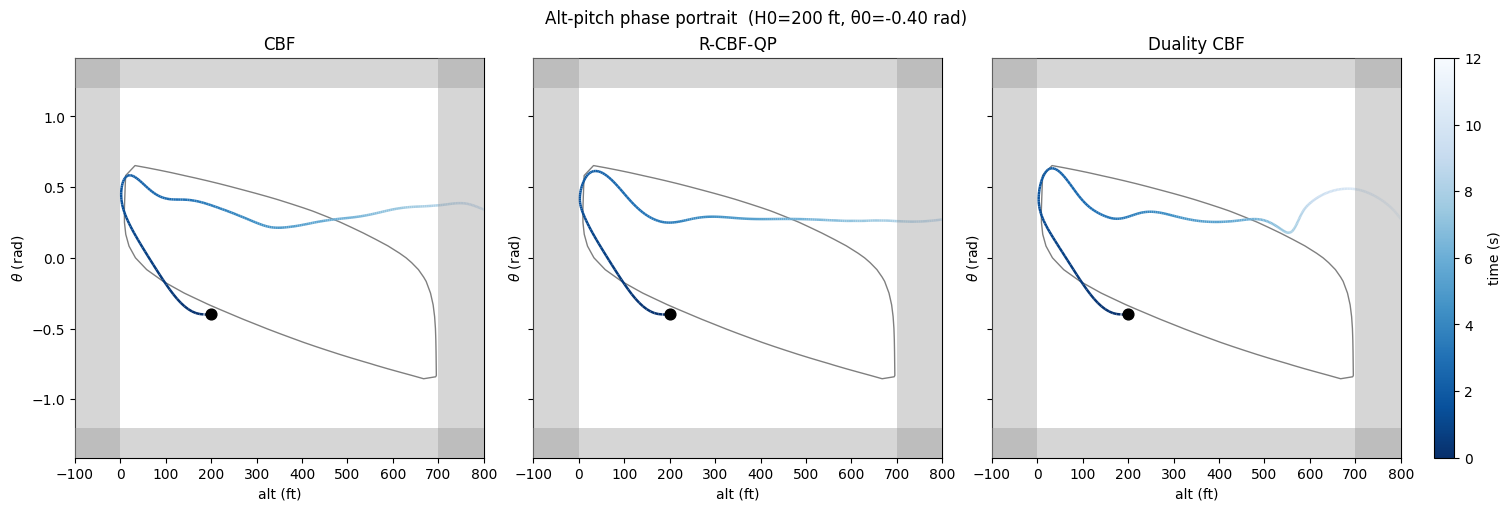

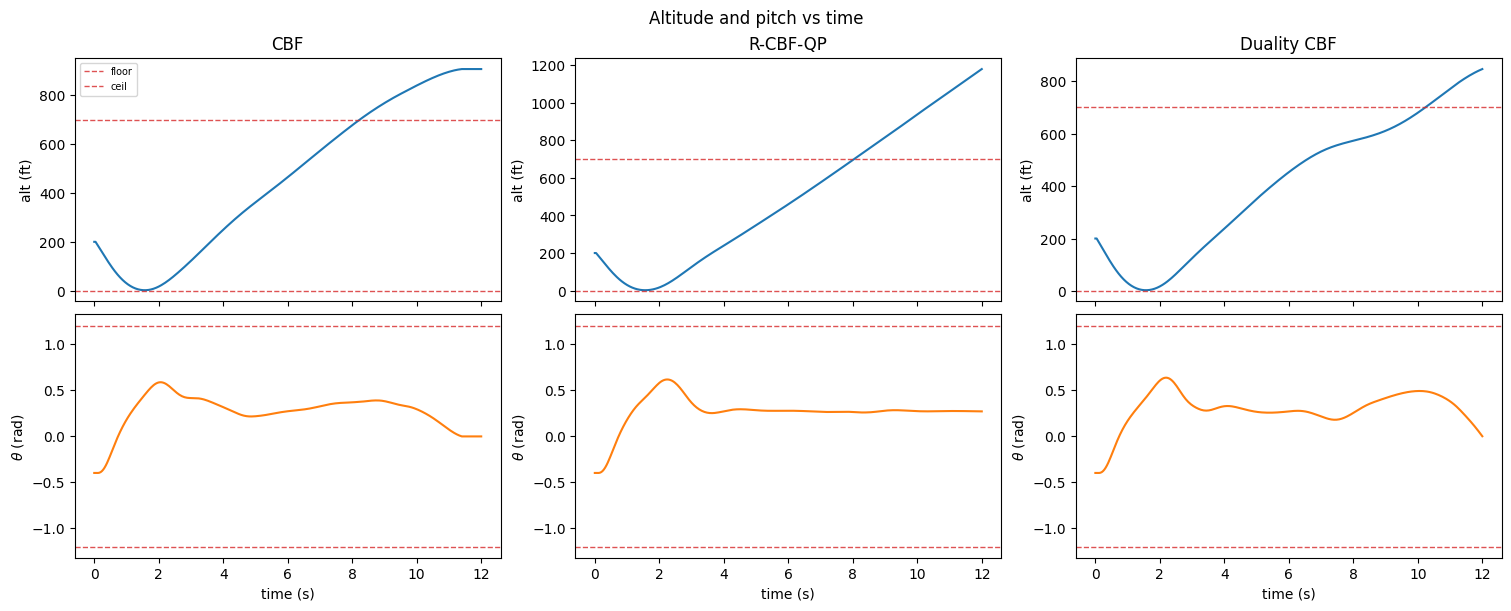

In [27]:
## Run CBF / R-CBF-QP / Duality CBF and plot

results = {}
for name, fn in [("CBF", rollout_cbf), ("R-CBF-QP", rollout_rcbf), ("Duality CBF", rollout_duality)]:
    xs, xhats, los, his = jax.device_get(fn(x0_demo))
    results[name] = dict(xs=xs, xhats=xhats, los=los, his=his)
    viol = bool(np.any(xs[:, task.H] < -1.0))   # altitude < -1 ft = floor violation
    print(f"  {name:<16}  alt_min={xs[:, task.H].min():.1f} ft  violated: {viol}")

ALL_ROLLOUTS = [(n, results[n]) for n in ["CBF", "R-CBF-QP", "Duality CBF"]]

# ── Alt-pitch phase portrait ──────────────────────────────────────────────────
n_pol = len(ALL_ROLLOUTS)
fig, axes = plt.subplots(1, n_pol, figsize=(5*n_pol, 5), layout='constrained',
                         sharex=True, sharey=True)
for ax, (name, d) in zip(axes, ALL_ROLLOUTS):
    xs = d['xs']
    pts  = np.stack([xs[:, task.H], xs[:, task.THETA]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='Blues_r',
                          norm=plt.Normalize(0, T*DT), lw=1.8, zorder=3)
    lc.set_array(np.arange(T+1)*DT)
    ax.add_collection(lc)
    ax.scatter(xs[0, task.H], xs[0, task.THETA], s=60, color='k', zorder=7)
    ax.scatter(xs[-1, task.H], xs[-1, task.THETA], s=40, color='navy', marker='*', zorder=7)
    # Vh=0 contour
    ax.contour(bb_Xs, bb_Ys, bb_Vh_max, levels=[0.0], colors=['k'],
               linewidths=1.0, alpha=0.5)
    task.plot_altpitch(ax)
    ax.set_title(name)
fig.colorbar(lc, ax=axes[-1], label='time (s)')
fig.suptitle(f'Alt-pitch phase portrait  (H0={float(x0_demo[task.H]):.0f} ft, θ0={float(x0_demo[task.THETA]):.2f} rad)')
plt.show()

# ── Altitude and pitch vs time ────────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, n_pol, figsize=(5*n_pol, 6), layout='constrained',
                            sharex=True)
for col, (name, d) in enumerate(ALL_ROLLOUTS):
    xs = d['xs']
    axes2[0, col].plot(ts, xs[:, task.H],     color='C0', lw=1.5)
    axes2[0, col].axhline(0.0,   color='C3', lw=1.0, ls='--', alpha=0.8, label='floor')
    axes2[0, col].axhline(700.0, color='C3', lw=1.0, ls='--', alpha=0.8, label='ceil')
    axes2[0, col].set_ylabel('alt (ft)')
    axes2[0, col].set_title(name)

    axes2[1, col].plot(ts, xs[:, task.THETA], color='C1', lw=1.5)
    axes2[1, col].axhline(-1.2, color='C3', lw=1.0, ls='--', alpha=0.8)
    axes2[1, col].axhline( 1.2, color='C3', lw=1.0, ls='--', alpha=0.8)
    axes2[1, col].set_ylabel(r'$\theta$ (rad)')
    axes2[1, col].set_xlabel('time (s)')
axes2[0, 0].legend(fontsize=7)
fig2.suptitle('Altitude and pitch vs time')
plt.show()

## Dual-Phi CBF: learning a scalar correction from dual-direction labels

For constraint $i$, the dual phi label at $\hat{x}$ is:
$$\phi_i(\hat{x}) = \max_j \max\bigl(0,\; [L_f V_i(\xi_j^*) + \alpha V_i(\xi_j^*)] - [L_f V_i(\hat{x}) + \alpha V_i(\hat{x})]\bigr)$$
where $\xi_j^* = \arg\max_{\xi\in[lo,hi]} \bigl[d_j^{(1:nu)}\cdot L_G V_i(\xi) + d_j^{(nu+1)}(L_f V_i(\xi)+\alpha V_i(\xi))\bigr]$
is found by sampling. The label accounts for joint variation in all CBF ingredients.

In [28]:
## Dual-phi: label function + dataset generation

_tb = jnp.array(task.train_bounds())   # (2, nx)

@jax.jit
def phi_dual_label(xhat, samp_key, alpha=ALPHA_QP):
    lo = jnp.clip(xhat - STATE_EPS, _tb[0], _tb[1])
    hi = jnp.clip(xhat + STATE_EPS, _tb[0], _tb[1])
    samples = lo[None] + jax.random.uniform(
        samp_key, (N_LABEL_SAMPLES, task.nx)) * (hi - lo)       # (N, nx)
    h_s, Lf_s, LG_s = jax.vmap(_gcbf_ingredients)(samples)     # (N,nh), (N,nh), (N,nh,nu)
    h_nom, Lf_nom, _ = _gcbf_ingredients(xhat)
    drift_nom = Lf_nom + alpha * h_nom                          # (nh,)
    phi = jnp.zeros(_NH)
    ci  = jnp.arange(_NH)
    for j in range(N_PLANES_DUAL):
        d0, d1, d2, d_lf = _DUAL_DIRS_PY[j]
        dual_obj = (d0 * LG_s[:, :, 0] + d1 * LG_s[:, :, 1] +
                    d2 * LG_s[:, :, 2] + d_lf * (Lf_s + alpha * h_s))  # (N, nh)
        best     = jnp.argmax(dual_obj, axis=0)                 # (nh,)
        drift_at = Lf_s[best, ci] + alpha * h_s[best, ci]       # (nh,)
        phi      = jnp.maximum(phi, jnp.maximum(0.0, drift_at - drift_nom))
    return phi   # (nh,) >= 0

# ── Generate training dataset ─────────────────────────────────────────────────
N_TRAIN_PHI = 4000
N_TEST_PHI  = 1000

rng_d = jax.random.PRNGKey(17)
rng_tr, rng_te = jax.random.split(rng_d)

# Sample states from training bounds
tb_lo, tb_hi = jnp.array(task.train_bounds())
x_tr = tb_lo + jax.random.uniform(rng_tr, (N_TRAIN_PHI, task.nx)) * (tb_hi - tb_lo)
x_te = tb_lo + jax.random.uniform(rng_te, (N_TEST_PHI,  task.nx)) * (tb_hi - tb_lo)

# Compute labels: vmap phi_dual_label over xhat + samp_key
print("Generating dual-phi training labels...")
keys_tr = jax.random.split(jax.random.PRNGKey(3), N_TRAIN_PHI)
keys_te = jax.random.split(jax.random.PRNGKey(4), N_TEST_PHI)
phi_tr = jax.vmap(phi_dual_label)(x_tr, keys_tr)    # (N_TRAIN, nh)
phi_te = jax.vmap(phi_dual_label)(x_te, keys_te)
phi_tr, phi_te = jax.device_get(phi_tr), jax.device_get(phi_te)
x_tr,   x_te   = jax.device_get(x_tr),   jax.device_get(x_te)

print(f"phi stats — mean: {phi_tr.mean():.4f}  std: {phi_tr.std():.4f}  "
      f"min: {phi_tr.min():.4f}  max: {phi_tr.max():.4f}")

Generating dual-phi training labels...
phi stats — mean: 0.1714  std: 0.3992  min: 0.0000  max: 15.3894


PhiNet params: 5898
Epoch 100  train_loss=1.32e-01  val_mse=1.34e-01
Epoch 200  train_loss=1.23e-01  val_mse=1.31e-01
Epoch 300  train_loss=1.82e-01  val_mse=1.32e-01


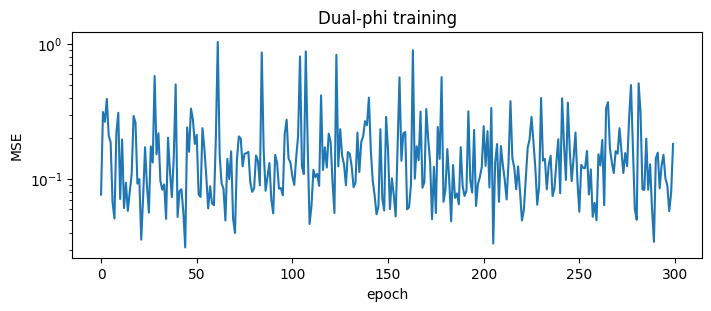

: 

In [ ]:
## Train PhiNet

class PhiNet(nn.Module):
    hidden_dims: tuple = (64, 64)
    n_constraints: int = _NH

    @nn.compact
    def __call__(self, xhat):
        x = xhat
        for h in self.hidden_dims:
            x = nn.Dense(h)(x)
            x = nn.tanh(x)
        return nn.softplus(nn.Dense(self.n_constraints)(x))   # phi >= 0

phi_net       = PhiNet()
phi_params    = phi_net.init(jax.random.PRNGKey(0), jnp.zeros(task.nx))['params']
phi_opt       = optax.adam(3e-3)
phi_opt_state = phi_opt.init(phi_params)
print(f"PhiNet params: {sum(p.size for p in jax.tree_util.tree_leaves(phi_params))}")

BATCH_SIZE_PHI = 64
N_EPOCHS_PHI   = 300

@jax.jit
def phi_train_step(params, opt_state, xhat_b, phi_b):
    def loss_fn(p):
        pred = jax.vmap(lambda x: phi_net.apply({'params': p}, x))(xhat_b)
        return jnp.mean((pred - phi_b) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt = phi_opt.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), new_opt, loss

rng_ep = jax.random.PRNGKey(99)
phi_losses = []
for epoch in range(N_EPOCHS_PHI):
    rng_ep, rng_sh = jax.random.split(rng_ep)
    perm = np.array(jax.random.permutation(rng_sh, N_TRAIN_PHI))
    for b in range(0, N_TRAIN_PHI, BATCH_SIZE_PHI):
        idx = perm[b : b + BATCH_SIZE_PHI]
        phi_params, phi_opt_state, loss = phi_train_step(
            phi_params, phi_opt_state,
            jnp.array(x_tr[idx]), jnp.array(phi_tr[idx]))
        loss = float(loss)
    phi_losses.append(loss)
    if (epoch + 1) % 100 == 0:
        pred_te = jax.vmap(lambda x: phi_net.apply({'params': phi_params}, x))(jnp.array(x_te))
        val_mse = float(jnp.mean((pred_te - jnp.array(phi_te)) ** 2))
        print(f"Epoch {epoch+1:3d}  train_loss={loss:.2e}  val_mse={val_mse:.2e}")

fig, ax = plt.subplots(figsize=(7, 3), layout='constrained')
ax.semilogy(phi_losses)
ax.set_xlabel('epoch'); ax.set_ylabel('MSE'); ax.set_title('Dual-phi training')
plt.show()

Compiling Dual-Phi rollout...
Done.
  Dual Phi          alt_min=-404.5 ft  violated: True


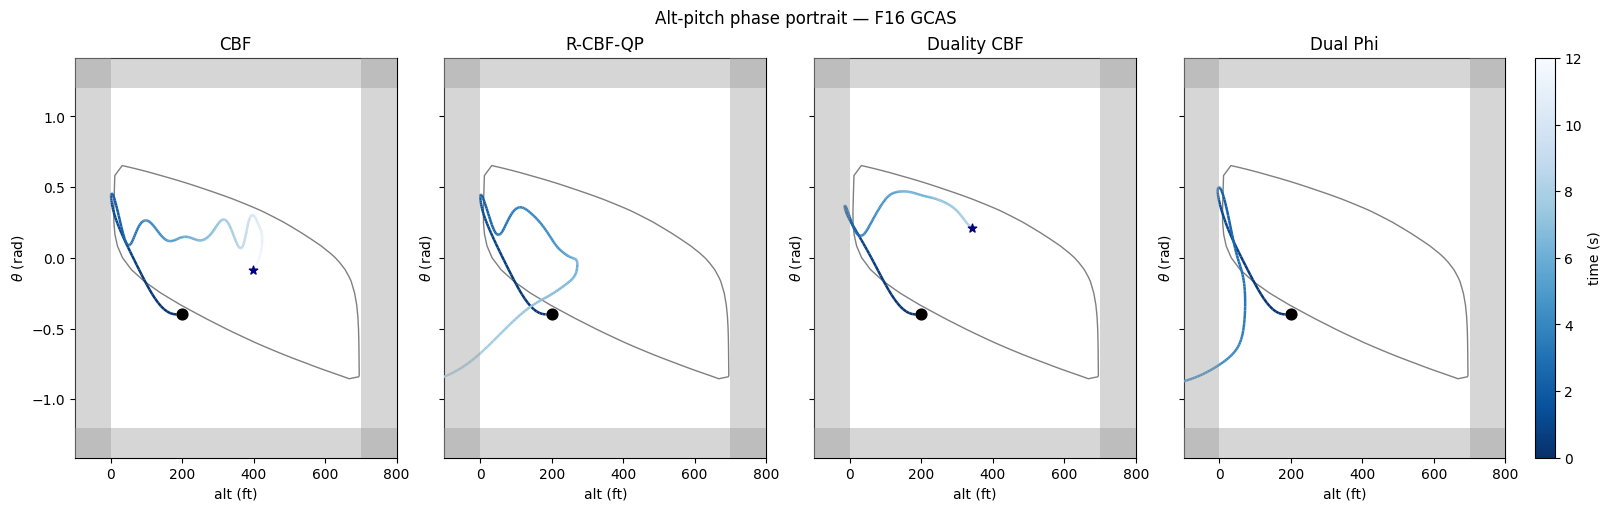

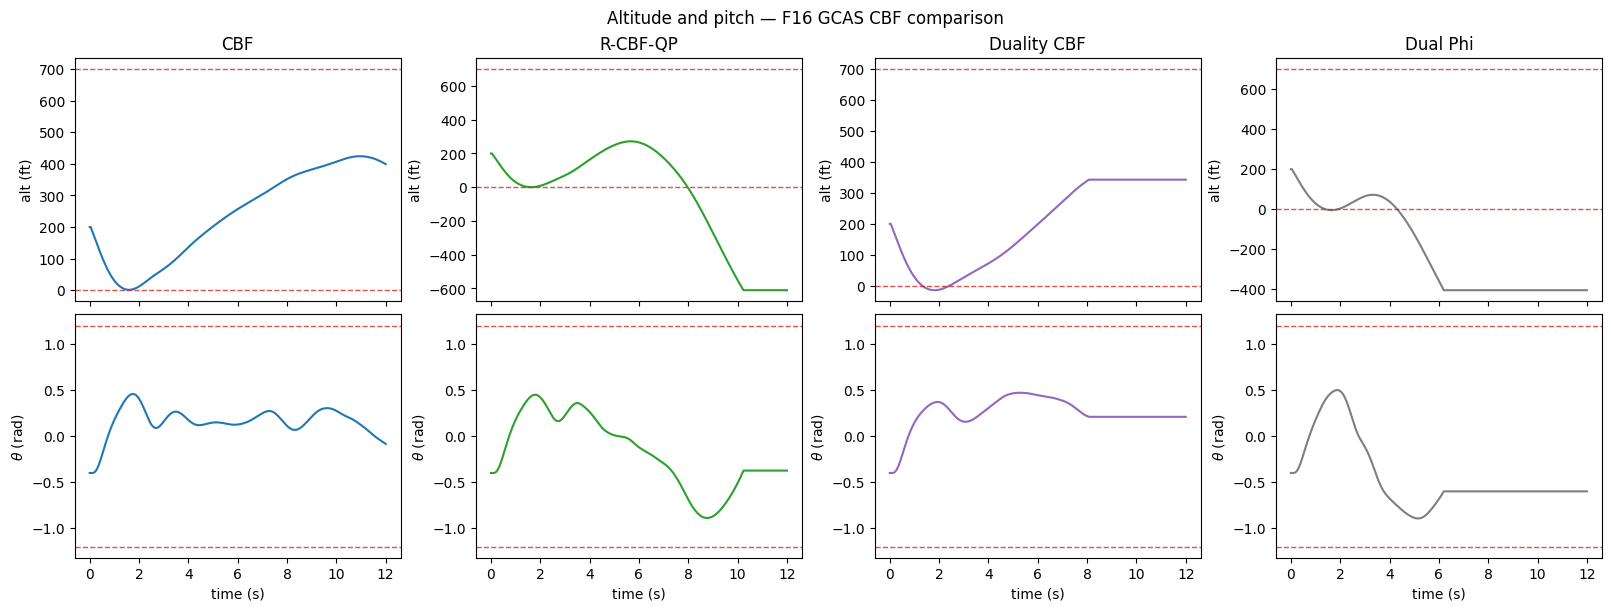


Timing (3 runs, T=300 steps)
  CBF               0.459 s  (1.53 ms/step)
  R-CBF-QP          0.518 s  (1.73 ms/step)
  Duality CBF       6.099 s  (20.33 ms/step)
  Dual Phi          0.432 s  (1.44 ms/step)


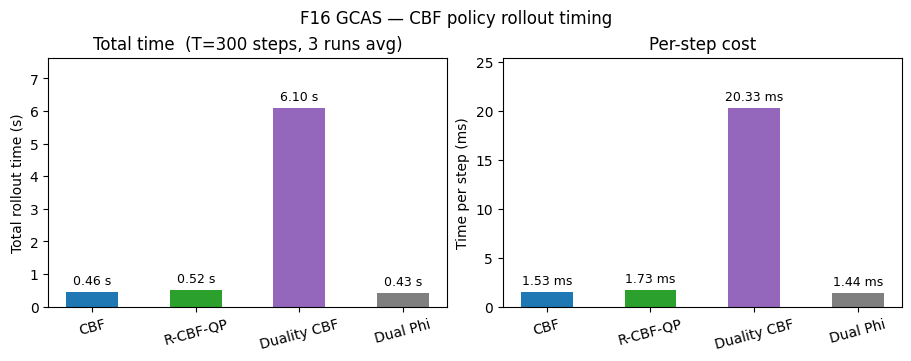

In [9]:
## Dual-Phi rollout + full comparison

_phi_params_frozen = phi_params

def _dual_phi_step(x, step_idx):
    key  = jax.random.fold_in(BASE_KEY, step_idx)
    xhat = _perturb_state(x, key)
    h_V   = B_nn(xhat)
    hx_Vx = jax.jacobian(B_nn)(xhat)
    phi   = phi_net.apply({'params': _phi_params_frozen}, xhat)   # (nh,)
    h_tight = h_V + phi / ALPHA_QP
    u_nom   = task.nom_pol_pid(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_tight, hx_Vx,
                            task.f(xhat), task.G(xhat), u_nom, relax_eps2=0.1)
    return x + DT * task.xdot(x, u), (x, xhat, xhat, xhat)

rollout_dual_phi = _make_rollout(_dual_phi_step)
print("Compiling Dual-Phi rollout...")
rollout_dual_phi(x_dummy)
print("Done.")

xs_dp, xhats_dp, los_dp, his_dp = jax.device_get(rollout_dual_phi(x0_demo))
results["Dual Phi"] = dict(xs=xs_dp, xhats=xhats_dp, los=los_dp, his=his_dp)
viol_dp = bool(np.any(xs_dp[:, task.H] < -1.0))
print(f"  {'Dual Phi':<16}  alt_min={xs_dp[:, task.H].min():.1f} ft  violated: {viol_dp}")

ALL_ROLLOUTS = [(n, results[n]) for n in ["CBF", "R-CBF-QP", "Duality CBF", "Dual Phi"]]

# ── Alt-pitch phase portrait (4 panels) ──────────────────────────────────────
n_pol = len(ALL_ROLLOUTS)
fig, axes = plt.subplots(1, n_pol, figsize=(4*n_pol, 5), layout='constrained',
                         sharex=True, sharey=True)
for ax, (name, d) in zip(axes, ALL_ROLLOUTS):
    xs = d['xs']
    pts  = np.stack([xs[:, task.H], xs[:, task.THETA]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='Blues_r',
                          norm=plt.Normalize(0, T*DT), lw=1.8, zorder=3)
    lc.set_array(np.arange(T+1)*DT)
    ax.add_collection(lc)
    ax.scatter(xs[0, task.H], xs[0, task.THETA],  s=60, color='k',    zorder=7)
    ax.scatter(xs[-1, task.H], xs[-1, task.THETA], s=40, color='navy', marker='*', zorder=7)
    ax.contour(bb_Xs, bb_Ys, bb_Vh_max, levels=[0.0], colors=['k'],
               linewidths=1.0, alpha=0.5)
    task.plot_altpitch(ax)
    ax.set_title(name)
fig.colorbar(lc, ax=axes[-1], label='time (s)')
fig.suptitle('Alt-pitch phase portrait — F16 GCAS')
plt.show()

# ── Altitude vs time (all 4 overlaid) ────────────────────────────────────────
fig2, axes2 = plt.subplots(2, n_pol, figsize=(4*n_pol, 6), layout='constrained',
                            sharex=True)
colors = ['C0', 'C2', 'C4', 'C7']
for col, ((name, d), color) in enumerate(zip(ALL_ROLLOUTS, colors)):
    xs = d['xs']
    axes2[0, col].plot(ts, xs[:, task.H], color=color, lw=1.5)
    axes2[0, col].axhline(0.0,   color='C3', lw=1.0, ls='--', alpha=0.8)
    axes2[0, col].axhline(700.0, color='C3', lw=1.0, ls='--', alpha=0.8)
    axes2[0, col].set_ylabel('alt (ft)')
    axes2[0, col].set_title(name)

    axes2[1, col].plot(ts, xs[:, task.THETA], color=color, lw=1.5)
    axes2[1, col].axhline(-1.2, color='C3', lw=1.0, ls='--', alpha=0.8)
    axes2[1, col].axhline( 1.2, color='C3', lw=1.0, ls='--', alpha=0.8)
    axes2[1, col].set_ylabel(r'$\theta$ (rad)')
    axes2[1, col].set_xlabel('time (s)')
fig2.suptitle('Altitude and pitch — F16 GCAS CBF comparison')
plt.show()

# ── Timing ────────────────────────────────────────────────────────────────────
N_REPEATS = 3
ROLLOUT_FNS = [("CBF", rollout_cbf), ("R-CBF-QP", rollout_rcbf),
               ("Duality CBF", rollout_duality), ("Dual Phi", rollout_dual_phi)]
print(f"\nTiming ({N_REPEATS} runs, T={T} steps)")
timing = {}
for name, fn in ROLLOUT_FNS:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(x0_demo))
        times.append(time.perf_counter() - t0)
    timing[name] = float(np.mean(times))
    print(f"  {name:<16}  {timing[name]:.3f} s  ({timing[name]/T*1000:.2f} ms/step)")
# ── Timing plot ───────────────────────────────────────────────────────────────
names  = list(timing.keys())
totals = [timing[n] for n in names]
per_step_ms = [timing[n] / T * 1000 for n in names]

fig3, axes3 = plt.subplots(1, 2, figsize=(9, 3.5), layout='constrained')
colors_bar = ['C0', 'C2', 'C4', 'C7']

bars0 = axes3[0].bar(names, totals, color=colors_bar, width=0.5)
axes3[0].bar_label(bars0, fmt='{:.2f} s', padding=3, fontsize=9)
axes3[0].set_ylabel('Total rollout time (s)')
axes3[0].set_title(f'Total time  (T={T} steps, {N_REPEATS} runs avg)')
axes3[0].set_ylim(0, max(totals) * 1.25)

bars1 = axes3[1].bar(names, per_step_ms, color=colors_bar, width=0.5)
axes3[1].bar_label(bars1, fmt='{:.2f} ms', padding=3, fontsize=9)
axes3[1].set_ylabel('Time per step (ms)')
axes3[1].set_title('Per-step cost')
axes3[1].set_ylim(0, max(per_step_ms) * 1.25)

for ax in axes3:
    ax.tick_params(axis='x', labelrotation=15)

fig3.suptitle('F16 GCAS — CBF policy rollout timing')
plt.show()